# What Are Embeddings

### Think of embeddings as a way to translate words into a language that computers understand - numbers!

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# simplified 2D example of word embeddings (real embeddings are typically 300+ dimensions)
word_embeddings = {
    "cat": [0.8, 0.6],
    "kitten": [0.75, 0.65],
    "dog": [0.7, 0.3],
    "puppy": [0.65, 0.35],
    "car": [-0.5, 0.2],
    "truck": [-0.45, 0.15]
}

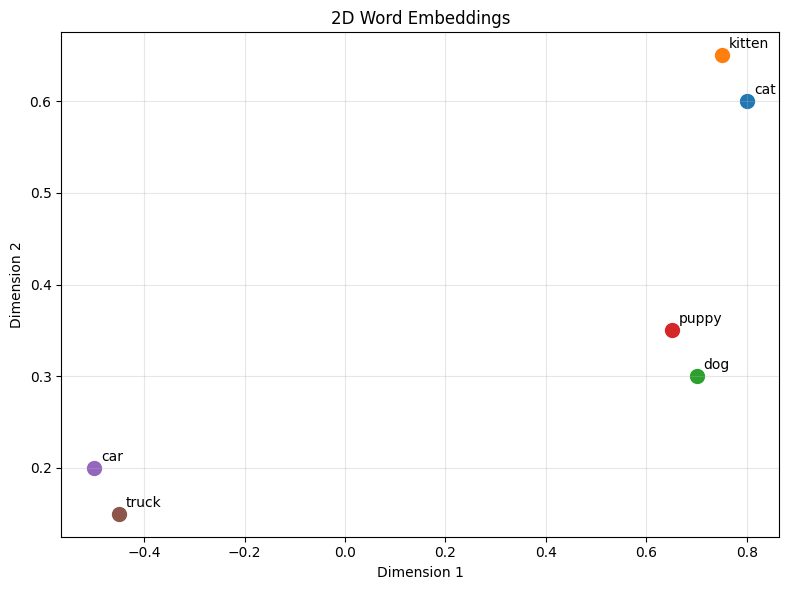

In [5]:
# create a figure and axis for plotting
# figure means the entire image, while axis is the area where we plot the data
# figsize=(8, 6) sets the size of the figure in inches (width, height)
# this is important for ensuring the plot is large enough to be clear and readable
# without this, the default size might be too small, especially when we have multiple points and labels
fig, ax = plt.subplots(figsize=(8, 6))

# plot each word embedding as a point on the graph
# we use a loop to go through each word and its corresponding embedding
for word, coords in word_embeddings.items():
    # scatter is used to plot individual points on the graph
    # coords[0] is the x-coordinate and coords[1] is the y-coordinate
    # s=100 sets the size of the points to make them more visible
    # plot means the actual drawing of the points on the graph, 
    # while scatter is a specific type of plot that is used for plotting individual points which, in others words
    # plots: a general term for any kind of graph or chart, including line plots, bar charts, histograms, etc.
    # scatter: a specific type of plot that is used to display individual data points, often with varying sizes and colors to represent additional dimensions of data
    ax.scatter(coords[0], coords[1], s=100)  # s=100 sets the size of the points


    # annotate is used to add text labels to the points on the graph
    # word is the text label (the word itself), and (coords[0], coords[1]) is the position where the label will be placed (the same as the point)
    # xytext=(5, 5) specifies an offset for the text label, so it doesn't overlap with the point itself, making it easier to read
    # textcoords='offset points' tells matplotlib that the xytext offset is in points, which is a unit of measurement for text and graphics in matplotlib
    ax.annotate(word, (coords[0], coords[1]), xytext=(5, 5), textcoords='offset points')  # add word labels with a small offset


# set the title and labels for the axes
ax.set_title("2D Word Embeddings")
ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")
# add a grid for better visibility of the points
# grid adds a background grid to the plot, which helps in visually aligning the points and understanding their relative positions
# alpha=0.3 sets the transparency of the grid lines, making them less prominent so they don't overpower the data points
ax.grid(True, alpha=0.3)

plt.tight_layout()  # adjust the layout to prevent overlap of elements
plt.show()  # display the plot

# Measuring Similarity
### using Cosine Similarity

In [6]:
def cosine_similarity(vec1, vec2):
    """Calculate the cosine similarity between two vectors.
    Cosine similarity is a measure of similarity between two non-zero vectors in an inner product space.
    It is defined as the cosine of the angle between them, which ranges from -1 (exactly opposite) to 1 (exactly the same), with 0 indicating orthogonality (no similarity).
    In the context of word embeddings, a higher cosine similarity indicates that the words represented by the vectors are more similar in meaning.
    - Result close to 1: The vectors are very similar (small angle between them).
    - Result close to 0: The vectors are orthogonal (unrelated).
    - Result close to -1: The vectors are opposite (large angle between them).
    """
    dot_product = np.dot(vec1, vec2)  # calculate the dot product of the two vectors
    norm_vec1 = np.linalg.norm(vec1)  # calculate the magnitude (norm) of the first vector
    norm_vec2 = np.linalg.norm(vec2)  # calculate the magnitude (norm) of the second vector
    if norm_vec1 == 0 or norm_vec2 == 0:  # check for zero-length vectors to avoid division by zero
        return 0.0
    return dot_product / (norm_vec1 * norm_vec2)  # return the cosine similarity value

In [7]:
cat_vector = [0.8, 0.6, 0.3]
kitten_vector = [0.75, 0.65, 0.5]
car_vector = [-0.5, 0.2, 0.1]

cat_kitten_similarity = cosine_similarity(cat_vector, kitten_vector)
cat_car_similarity = cosine_similarity(cat_vector, car_vector)
print(f"Cosine similarity between 'cat' and 'kitten': {cat_kitten_similarity:.4f}")
print(f"Cosine similarity between 'cat' and 'car': {cat_car_similarity:.4f}")

Cosine similarity between 'cat' and 'kitten': 0.9826
Cosine similarity between 'cat' and 'car': -0.4372


# Creating Your First Embeddings

### Huggingface and OpenAi Models

In [3]:
from langchain_huggingface import HuggingFaceEmbeddings

# Initialize a simple Embedding model ( No API key needed!)
embeddings = HuggingFaceEmbeddings(
  model_name = "sentence-transformers/all-MiniLM-L6-v2"
)
embeddings


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 930.69it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

In [4]:
text = "Hello,, I am learning about word embeddings!"

# embed_query: single string input, returns a single embedding vector
# embed_documents: list of strings input, returns a list of embedding vectors
embedding_vector = embeddings.embed_query(text=text)
print(f"Text: {text}")
print(f"Embedding length: {len(embedding_vector)}")
print(f"embedding_vector:\n{embedding_vector}") # print the first 5 values of the embedding vector for brevity

Text: Hello,, I am learning about word embeddings!
Embedding length: 384
embedding_vector:
[0.002059580059722066, -0.10227905213832855, 0.04649808257818222, -0.006492855958640575, -0.017441019415855408, 0.055613551288843155, 0.006906005088239908, 0.02146814577281475, 0.007763559930026531, 0.008804491721093655, 0.04271992668509483, 0.08273911476135254, 0.12198856472969055, 0.011862721294164658, -0.036623723804950714, 0.015346628613770008, 0.04024197533726692, 0.08687426149845123, -0.09968382865190506, -0.00686641177162528, 0.0010164659470319748, -0.006026619113981724, 0.06403018534183502, -0.0779704824090004, 0.06298980861902237, 0.010708414018154144, -0.08622849732637405, 0.024148019030690193, 0.07012208551168442, -0.050666965544223785, 0.03787290304899216, 0.007337138056755066, 0.009984363801777363, 0.07860419899225235, 0.012769202701747417, 0.06829248368740082, -0.004803598392754793, 0.013838307932019234, -0.026545103639364243, 0.013131367973983288, -0.0045517198741436005, 0.00761719

In [7]:
# using embed_documents to embed multiple texts at once
sentences = [
    "I love machine learning.",
    "I love machine learning.",
    "The cat is on the roof.",
    "This is a sentence embedding example.",
    "I love programming in Python.",
    "Embeddings are useful for many NLP tasks."
]

embedding_vectors = embeddings.embed_documents(sentences)
for sentence, vector in zip(sentences, embedding_vectors):
    print(f"Sentence: {sentence}")
    print(f"Embedding length: {len(vector)}")
    print(f"embedding_vector:\n{vector}\n") # print the first 5 values of the embedding vector for brevity


Sentence: I love machine learning.
Embedding length: 384
embedding_vector:
[-0.016851074993610382, -0.07072184979915619, 0.08554094284772873, -0.0017660805024206638, 0.045208822935819626, -0.053112126886844635, -0.048555243760347366, -0.031039103865623474, 0.01999199204146862, 0.0013778589200228453, -0.05642637610435486, 0.08474869281053543, 0.03135887533426285, -0.009936279617249966, -0.02516184002161026, 0.01564570516347885, -0.05058755353093147, 0.010036700405180454, -0.09949710965156555, -0.1103643998503685, -0.05488483980298042, 0.0130549231544137, 0.0016937371110543609, 0.001015044399537146, 0.028596097603440285, 0.014572464860975742, 0.020524270832538605, -0.008306236006319523, -0.014727797359228134, -0.05601467937231064, -0.012392700649797916, 0.05011456459760666, 0.0008125860476866364, 0.03934534639120102, -0.08508964627981186, 0.021291319280862808, 0.01746693253517151, 0.032956916838884354, 0.017330149188637733, 0.03569190204143524, -0.026970839127898216, -0.00045759807107970